In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist


Starting Samples:


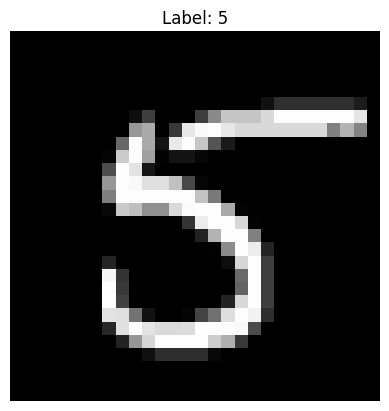

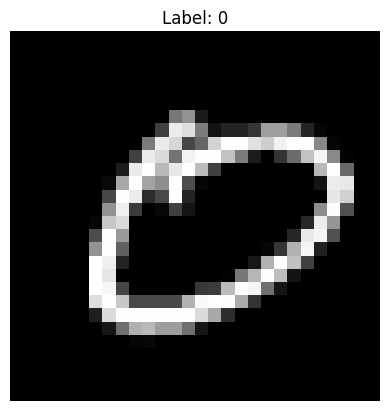

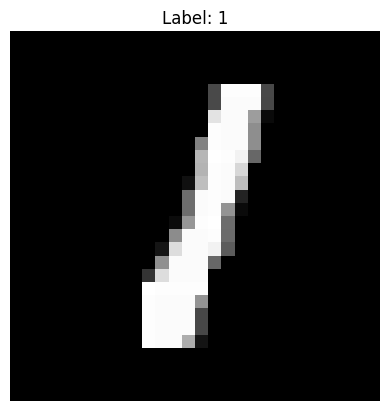

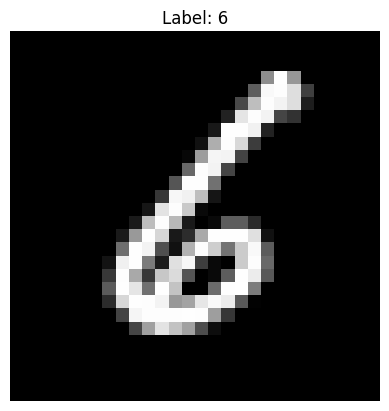

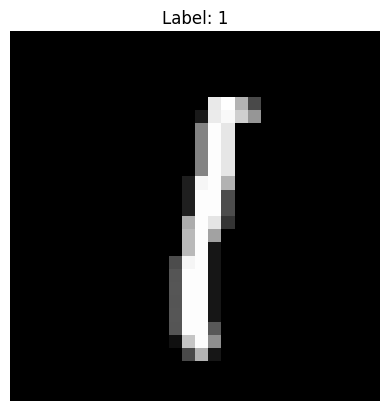

In [2]:
# Load MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Normalize data to [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 -> 784)
X_train_full = X_train_full.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Print starting samples
print("Starting Samples:")
for i in range(5):
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()


In [3]:
# Input layer
input_dim = X_train.shape[1]  # 784
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # Latent space

# Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)

# Encoder model (to extract latent space)
encoder = Model(input_layer, encoded)

# Compile the model
autoencoder.compile(optimizer=Adam(), loss='mse')

# Print model summary
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train the autoencoder
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_val, X_val),
    verbose=2
)


Epoch 1/20
188/188 - 3s - 18ms/step - loss: 0.0694 - val_loss: 0.0400
Epoch 2/20
188/188 - 2s - 10ms/step - loss: 0.0344 - val_loss: 0.0295
Epoch 3/20
188/188 - 2s - 9ms/step - loss: 0.0257 - val_loss: 0.0234
Epoch 4/20
188/188 - 2s - 10ms/step - loss: 0.0221 - val_loss: 0.0209
Epoch 5/20
188/188 - 2s - 10ms/step - loss: 0.0201 - val_loss: 0.0195
Epoch 6/20
188/188 - 2s - 10ms/step - loss: 0.0187 - val_loss: 0.0181
Epoch 7/20
188/188 - 2s - 10ms/step - loss: 0.0175 - val_loss: 0.0172
Epoch 8/20
188/188 - 2s - 11ms/step - loss: 0.0166 - val_loss: 0.0163
Epoch 9/20
188/188 - 2s - 10ms/step - loss: 0.0159 - val_loss: 0.0157
Epoch 10/20
188/188 - 2s - 9ms/step - loss: 0.0154 - val_loss: 0.0153
Epoch 11/20
188/188 - 2s - 8ms/step - loss: 0.0150 - val_loss: 0.0150
Epoch 12/20
188/188 - 2s - 8ms/step - loss: 0.0146 - val_loss: 0.0146
Epoch 13/20
188/188 - 2s - 10ms/step - loss: 0.0142 - val_loss: 0.0142
Epoch 14/20
188/188 - 2s - 12ms/step - loss: 0.0139 - val_loss: 0.0139
Epoch 15/20
188/188

Test Loss (MSE): 0.0118
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Original and Reconstructed Samples:


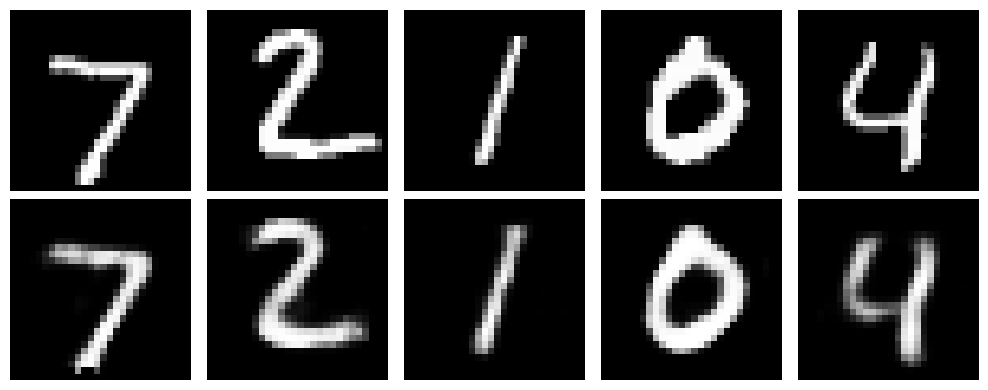

In [5]:
# Evaluate on test set
test_loss = autoencoder.evaluate(X_test, X_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.4f}")

# Visualize original vs reconstructed images
reconstructed = autoencoder.predict(X_test)

print("Original and Reconstructed Samples:")
num_images = 5
plt.figure(figsize=(10, 4))
for i in range(num_images):
    # Original
    plt.subplot(2, num_images, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("Original")

    # Reconstructed
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("Reconstructed")
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


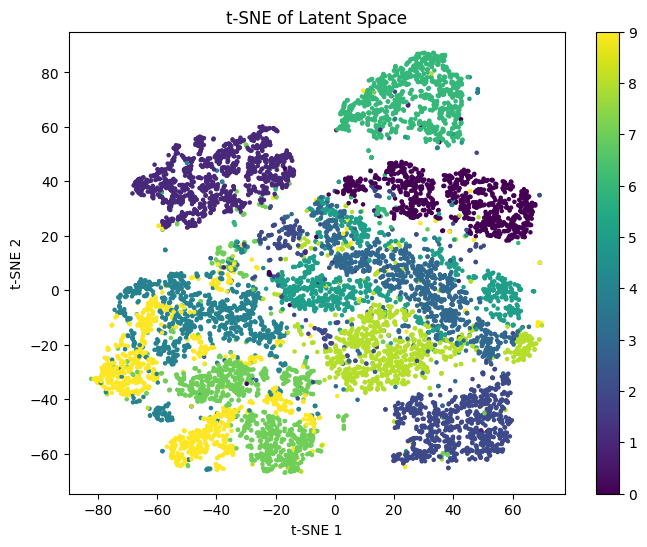

In [6]:
# Extract latent representations
latent_representations = encoder.predict(X_test)

# Visualize latent space using t-SNE
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_representations)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test, cmap='viridis', s=5)
plt.colorbar()
plt.title("t-SNE of Latent Space")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


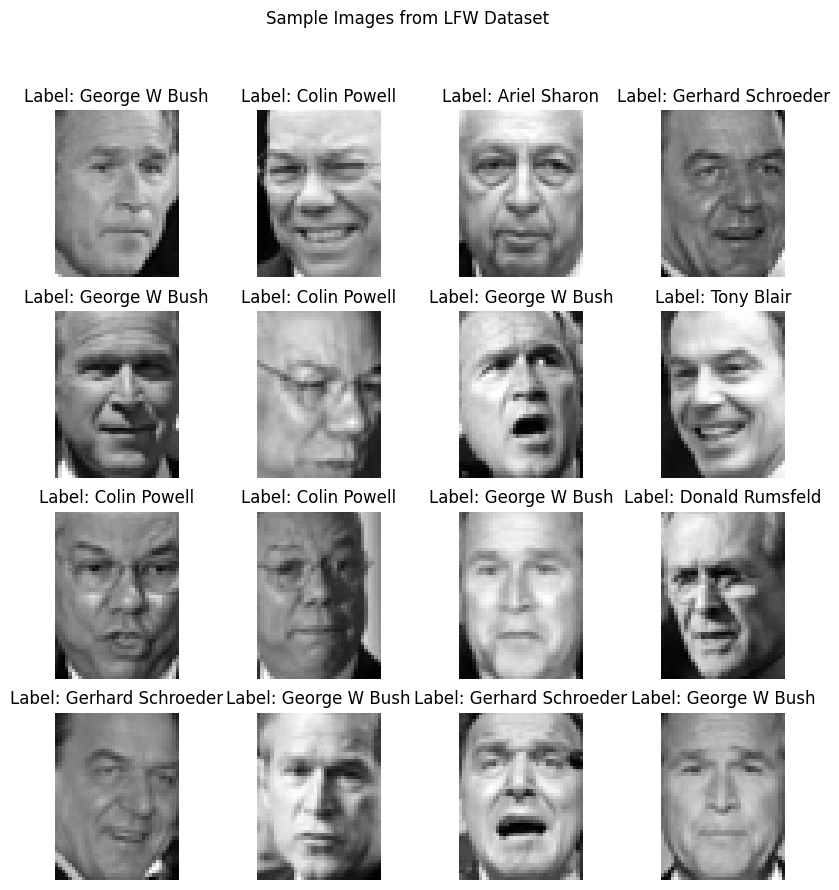

In [3]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt

# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Get the images and labels
X = lfw_people.images
y = lfw_people.target

# Plot some example images
num_images = 16
plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {lfw_people.target_names[y[i]]}")
    plt.axis('off')
plt.suptitle("Sample Images from LFW Dataset")
plt.show()


In [4]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.manifold import TSNE

# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X = lfw_people.images
y = lfw_people.target
X_flat = X.reshape(X.shape[0], -1)  # Flatten the images for the neural network

# Train-test split
X_train, X_test = train_test_split(X_flat, test_size=0.2, random_state=42)

In [5]:
# Build the autoencoder model
input_layer = layers.Input(shape=(X_train.shape[1],))
encoder = layers.Dense(128, activation='relu')(input_layer)
encoder = layers.Dense(64, activation='relu')(encoder)
decoder = layers.Dense(128, activation='relu')(encoder)
output_layer = layers.Dense(X_train.shape[1], activation='sigmoid')(decoder)

autoencoder = models.Model(input_layer, output_layer)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, validation_data=(X_test, X_test))

# Evaluate the model on the testing set
test_loss = autoencoder.evaluate(X_test, X_test)
print(f"Test loss (Reconstruction error): {test_loss}")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0307 - val_loss: 0.0289
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0279 - val_loss: 0.0257
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0248 - val_loss: 0.0233
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0226 - val_loss: 0.0225
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0219 - val_loss: 0.0223
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0214 - val_loss: 0.0219
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0211 - val_loss: 0.0215
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0209 - val_loss: 0.0211
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0202 - val_loss: 0.0206
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0199 - val_loss: 0.0201
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0191 - val_loss: 0.0195
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0183 - val_loss: 0.0190
E

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


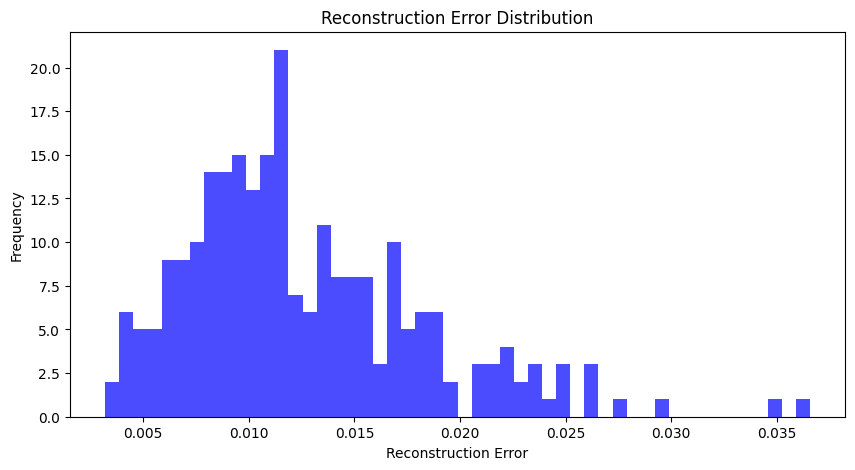

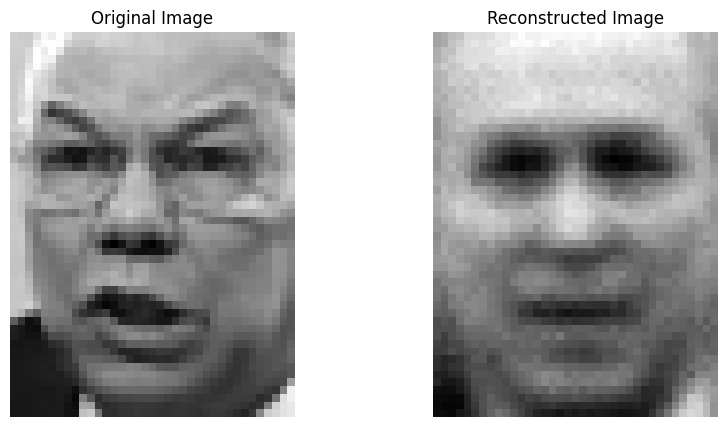

In [6]:
# Visualize the reconstruction error
reconstructed_images = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.square(X_test - reconstructed_images), axis=1)

plt.figure(figsize=(10, 5))
plt.hist(reconstruction_error, bins=50, color='blue', alpha=0.7)
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.show()

# Visualize the comparison between original and reconstructed data for the first image in the test set
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_test[0].reshape(50, 37), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_images[0].reshape(50, 37), cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


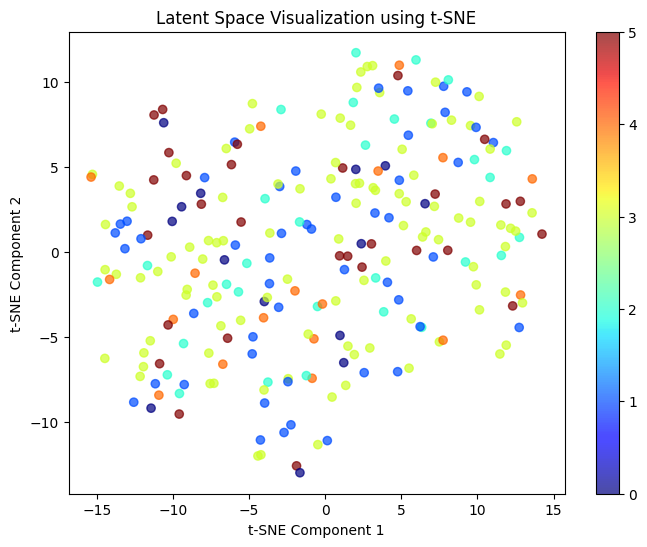

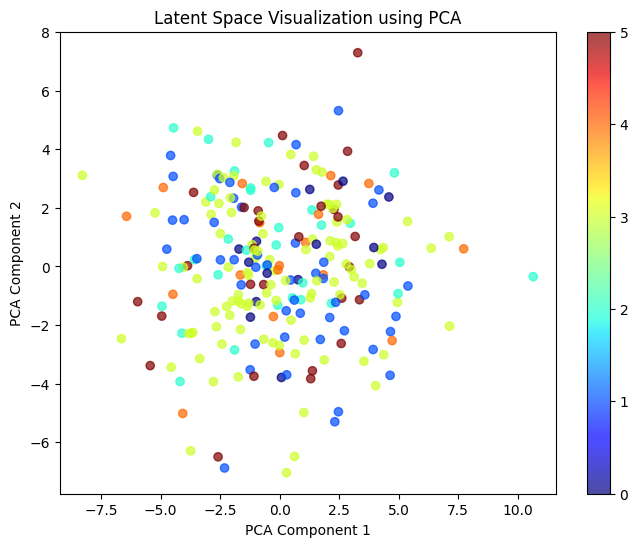

In [7]:
# Extract the latent space (the output of the encoder)
encoder_model = models.Model(input_layer, encoder)
latent_space = encoder_model.predict(X_test)

# Visualize the latent space using t-SNE
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_space)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y[:len(latent_2d)], cmap='jet', alpha=0.7)
plt.colorbar()
plt.title("Latent Space Visualization using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

# Alternatively, you can use PCA for a linear projection of the latent space
pca = PCA(n_components=2)
latent_2d_pca = pca.fit_transform(latent_space)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=y[:len(latent_2d_pca)], cmap='jet', alpha=0.7)
plt.colorbar()
plt.title("Latent Space Visualization using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
